# 📐 Part 3: 2DOF Analytical Inverse Kinematics

목표 좌표 $(x_d, y_d)$로부터 각 관절의 각도 $\theta_1, \theta_2$를 계산하는 **역기구학(Inverse Kinematics, IK)** 실습이다. 2자유도 로봇의 해석적(Analytical) 해를 구한다.

## 1. 제2코사인 법칙 기반 IK 공식

기하학적 삼각형 관계로부터 유도되는 IK 공식이다. 도달 한계를 벗어나면 해가 존재하지 않는다.

$$
\cos\theta_2 = \frac{x_d^2 + y_d^2 - L_1^2 - L_2^2}{2 L_1 L_2}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

L1, L2 = 0.3, 0.3

def ik_2dof(xd, yd, elbow_up=True):
    """2자유도 로봇의 해석적 역기구학 해결사 (수치 오차 방지 버전)"""
    # 1. cos(theta2) 공식 계산
    cos_t2 = (xd**2 + yd**2 - L1**2 - L2**2) / (2 * L1 * L2)
    
    # 2. 예외 처리: 허용 오차(1e-9)를 주어 부동소수점 오차 방지
    if np.abs(cos_t2) > 1.0 + 1e-9:
        raise ValueError(f"도달 불가능 영역입니다. 목표거리: {np.hypot(xd, yd):.3f}m (로봇 팔 최대 도달 길이: {L1+L2:.3f}m)")
        
    # 부동소수점 오차로 인해 1.0을 아주 미세하게 초과한 값을 [-1.0, 1.0] 범위로 고정
    cos_t2 = np.clip(cos_t2, -1.0, 1.0)
        
    # 3. theta2 계산 (Elbow-up: -부호, Elbow-down: +부호)
    sin_t2 = np.sqrt(1.0 - cos_t2**2)
    t2 = -np.arctan2(sin_t2, cos_t2) if elbow_up else np.arctan2(sin_t2, cos_t2)
    
    # 4. theta1 계산
    t1 = np.arctan2(yd, xd) - np.arctan2(L2 * np.sin(t2), L1 + L2 * np.cos(t2))
    
    return np.degrees(t1), np.degrees(t2)


목표 (0.4, 0.2) 도달 성공!
  - Elbow-Up  : theta1=68.4°, theta2=-83.6°
  - Elbow-Down: theta1=-15.2°, theta2=83.6°
목표 (0.7, 0.0) 실패: 도달 불가능 영역입니다. 목표거리: 0.700m (로봇 팔 최대 도달 길이: 0.600m)


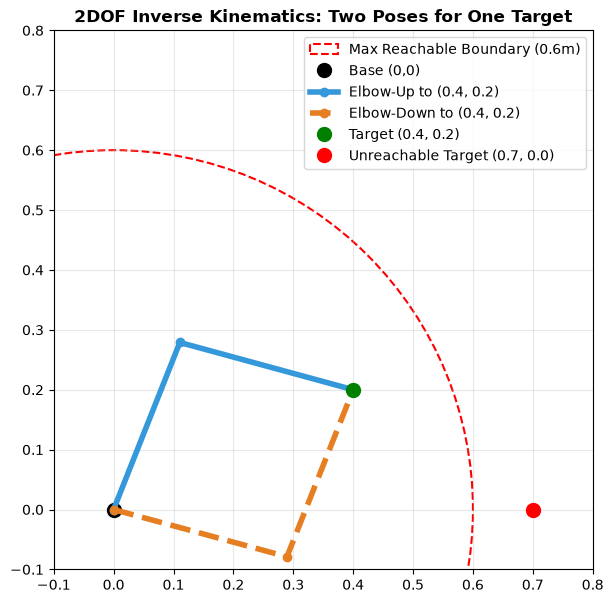

In [2]:
# 예제 1: 도달 테스트 및 복수 해(Elbow-Up/Down) 동시 시각화
targets = [(0.4, 0.2), (0.7, 0.0)] # (0.7, 0.0)은 도달 불가

plt.figure(figsize=(7, 7))

# 1. 로봇 팔의 최대 도달 한계 영역 그리기 (반경: L1 + L2 = 0.6m)
outer_circle = plt.Circle((0, 0), L1 + L2, color='red', fill=False, linestyle='--', linewidth=1.5, label='Max Reachable Boundary (0.6m)')
plt.gca().add_patch(outer_circle)

# 2. 로봇 베이스(원점) 표시
plt.plot(0, 0, 'ko', markersize=10, label='Base (0,0)')

# 3. 목표물 및 도달 가능한 경우의 두 가지 해 시각화
for x, y in targets:
    try:
        # A. Elbow-Up 해 계산 및 조인트 위치 구하기
        t1_u, t2_u = ik_2dof(x, y, elbow_up=True)
        t1_u_rad, t2_u_rad = np.radians(t1_u), np.radians(t2_u)
        p0 = np.array([0.0, 0.0])
        p1_u = np.array([L1 * np.cos(t1_u_rad), L1 * np.sin(t1_u_rad)])
        p2_u = p1_u + np.array([L2 * np.cos(t1_u_rad + t2_u_rad), L2 * np.sin(t1_u_rad + t2_u_rad)])
        
        # B. Elbow-Down 해 계산 및 조인트 위치 구하기
        t1_d, t2_d = ik_2dof(x, y, elbow_up=False)
        t1_d_rad, t2_d_rad = np.radians(t1_d), np.radians(t2_d)
        p1_d = np.array([L1 * np.cos(t1_d_rad), L1 * np.sin(t1_d_rad)])
        p2_d = p1_d + np.array([L2 * np.cos(t1_d_rad + t2_d_rad), L2 * np.sin(t1_d_rad + t2_d_rad)])

        print(f"목표 ({x}, {y}) 도달 성공!")
        print(f"  - Elbow-Up  : theta1={t1_u:.1f}°, theta2={t2_u:.1f}°")
        print(f"  - Elbow-Down: theta1={t1_d:.1f}°, theta2={t2_d:.1f}°")
        
        # Elbow-Up 포즈: 파란색 실선
        plt.plot([p0[0], p1_u[0], p2_u[0]], [p0[1], p1_u[1], p2_u[1]], 'o-', color='#3498db', lw=4, label=f'Elbow-Up to ({x}, {y})')
        # Elbow-Down 포즈: 주황색 점선
        plt.plot([p0[0], p1_d[0], p2_d[0]], [p0[1], p1_d[1], p2_d[1]], 'o--', color='#e67e22', lw=4, label=f'Elbow-Down to ({x}, {y})')
        
        # 목표 지점을 초록색 점으로 표시
        plt.plot(x, y, 'go', markersize=10, label=f'Target ({x}, {y})')
        
    except ValueError as e:
        print(f"목표 ({x}, {y}) 실패: {e}")
        # 도달하지 못하는 목표물 (빨간색 점) 그리기
        plt.plot(x, y, 'ro', markersize=10, label=f'Unreachable Target ({x}, {y})')

# 그래프 스타일 및 축 설정
plt.xlim(-0.1, 0.8)
plt.ylim(-0.1, 0.8)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')
plt.title("2DOF Inverse Kinematics: Two Poses for One Target", fontsize=12, fontweight='bold')
plt.legend()
plt.show()


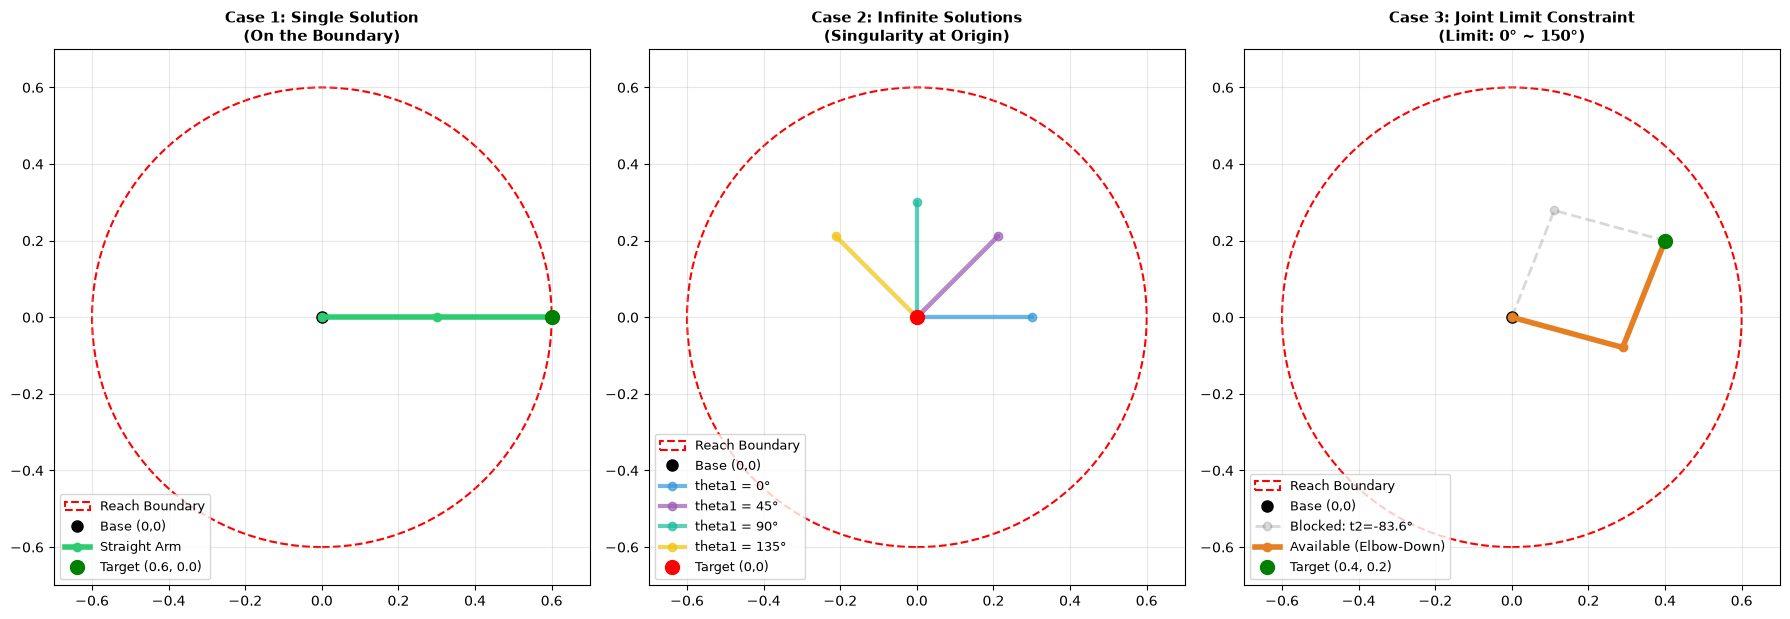

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 링크 길이 정의
L1, L2 = 0.3, 0.3

# 2. 로컬 순기구학 함수 정의 (셀 순서 에러 방지)
def local_fk_positions(t1_deg, t2_deg):
    t1 = np.radians(t1_deg)
    t2 = np.radians(t2_deg)
    p0 = np.array([0.0, 0.0])
    p1 = np.array([L1 * np.cos(t1), L1 * np.sin(t1)])
    p2 = p1 + np.array([L2 * np.cos(t1 + t2), L2 * np.sin(t1 + t2)])
    return p0, p1, p2

# 3. 로컬 수치 에러 보정 역기구학 함수 정의 (안전 장치)
def safe_ik_2dof(xd, yd, elbow_up=True):
    cos_t2 = (xd**2 + yd**2 - L1**2 - L2**2) / (2 * L1 * L2)
    # 수치적 부동소수점 오차 보정 (-1.0 ~ 1.0 범위로 고정)
    cos_t2 = np.clip(cos_t2, -1.0, 1.0)
    
    sin_t2 = np.sqrt(1.0 - cos_t2**2)
    t2 = -np.arctan2(sin_t2, cos_t2) if elbow_up else np.arctan2(sin_t2, cos_t2)
    t1 = np.arctan2(yd, xd) - np.arctan2(L2 * np.sin(t2), L1 + L2 * np.cos(t2))
    return np.degrees(t1), np.degrees(t2)

# ----------------------------------------------------
# 시각화 설정 (3개 서브플롯)
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

def setup_axis(ax, title):
    outer_circle = plt.Circle((0, 0), L1 + L2, color='red', fill=False, linestyle='--', linewidth=1.5, label='Reach Boundary')
    ax.add_patch(outer_circle)
    ax.plot(0, 0, 'ko', markersize=8, label='Base (0,0)')
    ax.set_xlim(-0.7, 0.7)
    ax.set_ylim(-0.7, 0.7)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11, fontweight='bold')

# ----------------------------------------------------
# Case 1: 해가 1개만 존재하는 경우 (경계선 위치)
# ----------------------------------------------------
ax1 = axs[0]
setup_axis(ax1, "Case 1: Single Solution\n(On the Boundary)")
xt1, yd1 = 0.6, 0.0  # 경계선 지점

# safe_ik_2dof를 호출하여 오차 없이 계산
t1_u, t2_u = safe_ik_2dof(xt1, yd1, elbow_up=True)
p0, p1, p2 = local_fk_positions(t1_u, t2_u)

ax1.plot([p0[0], p1[0], p2[0]], [p0[1], p1[1], p2[1]], 'o-', color='#2ecc71', lw=4, label='Straight Arm')
ax1.plot(xt1, yd1, 'go', markersize=10, label=f'Target ({xt1}, {yd1})')
ax1.legend(loc='lower left', fontsize=9)

# ----------------------------------------------------
# Case 2: 해가 무한한 경우 (특이점 - 원점 위치)
# ----------------------------------------------------
ax2 = axs[1]
setup_axis(ax2, "Case 2: Infinite Solutions\n(Singularity at Origin)")
xt2, yt2 = 0.0, 0.0

test_theta1s = [0, 45, 90, 135]
colors = ['#3498db', '#9b59b6', '#1abc9c', '#f1c40f']

for t1_deg, color in zip(test_theta1s, colors):
    p0, p1, p2 = local_fk_positions(t1_deg, -180.0)
    ax2.plot([p0[0], p1[0], p2[0]], [p0[1], p1[1], p2[1]], 'o-', color=color, alpha=0.7, lw=3, label=f'theta1 = {t1_deg}°')

ax2.plot(xt2, yt2, 'ro', markersize=10, label='Target (0,0)')
ax2.legend(loc='lower left', fontsize=9)

# ----------------------------------------------------
# Case 3: 물리적 관절 제한에 의해 해가 1개로 필터링되는 경우
# ----------------------------------------------------
ax3 = axs[2]
setup_axis(ax3, "Case 3: Joint Limit Constraint\n(Limit: 0° ~ 150°)")
xt3, yt3 = 0.4, 0.2

# 제한 범위: 관절 2는 양수(반시계 방향) 각도로만 작동 가능 가정
joint2_min, joint2_max = 0.0, 150.0

t1_u, t2_u = safe_ik_2dof(xt3, yt3, elbow_up=True)
p0, p1_u, p2_u = local_fk_positions(t1_u, t2_u)

t1_d, t2_d = safe_ik_2dof(xt3, yt3, elbow_up=False)
p0, p1_d, p2_d = local_fk_positions(t1_d, t2_d)

if joint2_min <= t2_u <= joint2_max:
    ax3.plot([p0[0], p1_u[0], p2_u[0]], [p0[1], p1_u[1], p2_u[1]], 'o-', color='#3498db', lw=4, label='Available (Elbow-Up)')
else:
    ax3.plot([p0[0], p1_u[0], p2_u[0]], [p0[1], p1_u[1], p2_u[1]], 'o--', color='grey', alpha=0.3, lw=2, label=f'Blocked: t2={t2_u:.1f}°')

if joint2_min <= t2_d <= joint2_max:
    ax3.plot([p0[0], p1_d[0], p2_d[0]], [p0[1], p1_d[1], p2_d[1]], 'o-', color='#e67e22', lw=4, label='Available (Elbow-Down)')
else:
    ax3.plot([p0[0], p1_d[0], p2_d[0]], [p0[1], p1_d[1], p2_d[1]], 'o--', color='grey', alpha=0.3, lw=2, label=f'Blocked: t2={t2_d:.1f}°')

ax3.plot(xt3, yt3, 'go', markersize=10, label=f'Target ({xt3}, {yt3})')
ax3.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()


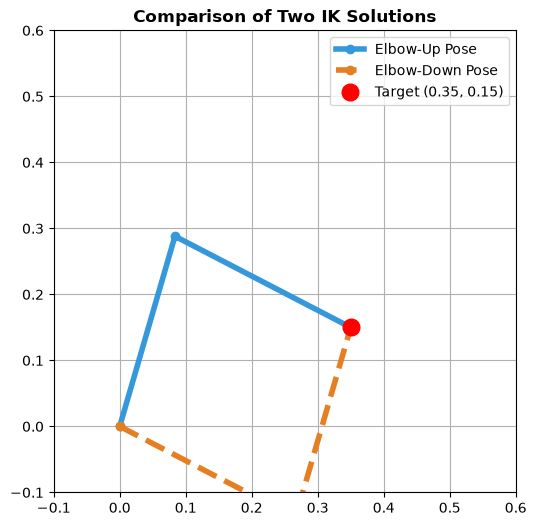

In [6]:
def get_fk_positions(t1_deg, t2_deg):
    t1 = np.radians(t1_deg)
    t2 = np.radians(t2_deg)
    p0 = np.array([0.0, 0.0])
    p1 = np.array([L1 * np.cos(t1), L1 * np.sin(t1)])
    p2 = p1 + np.array([L2 * np.cos(t1 + t2), L2 * np.sin(t1 + t2)])
    return p0, p1, p2

xd, yd = 0.35, 0.15
t1_u, t2_u = ik_2dof(xd, yd, elbow_up=True)
t1_d, t2_d = ik_2dof(xd, yd, elbow_up=False)

p0, p1_u, p2_u = get_fk_positions(t1_u, t2_u)
_, p1_d, p2_d = get_fk_positions(t1_d, t2_d)

plt.figure(figsize=(6, 6))
plt.plot([p0[0], p1_u[0], p2_u[0]], [p0[1], p1_u[1], p2_u[1]], 'o-', color='#3498db', lw=4, label='Elbow-Up Pose')
plt.plot([p0[0], p1_d[0], p2_d[0]], [p0[1], p1_d[1], p2_d[1]], 'o--', color='#e67e22', lw=4, label='Elbow-Down Pose')
plt.plot(xd, yd, 'ro', markersize=12, label=f'Target ({xd}, {yd})')

plt.xlim(-0.1, 0.6)
plt.ylim(-0.1, 0.6)
plt.grid(True)
plt.gca().set_aspect('equal')
plt.legend()
plt.title("Comparison of Two IK Solutions", fontsize=12, fontweight='bold')
plt.show()

## 3. 경로 추적 시각화

지정된 원형 경로 상의 모든 점들에 대해 연속적으로 IK를 계산하고 관절각의 변화를 관측한다.

용접이나 글씨, 커팅 작업 등

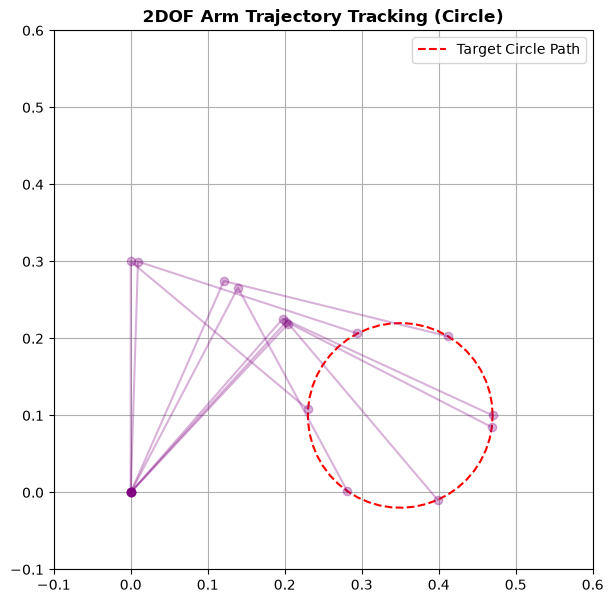

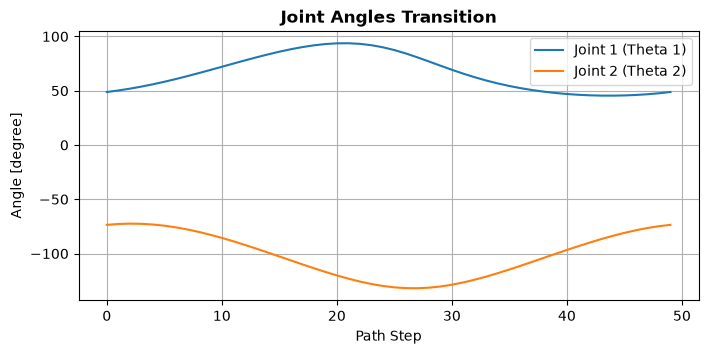

In [7]:
# 예제 3: 원형 경로 추적하기
num_points = 50
theta_circle = np.linspace(0, 2*np.pi, num_points)

# 원의 중심 (0.35, 0.1), 반경 R=0.12
circle_x = 0.35 + 0.12 * np.cos(theta_circle)
circle_y = 0.10 + 0.12 * np.sin(theta_circle)

theta1_history = []
theta2_history = []

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(circle_x, circle_y, 'r--', label='Target Circle Path')

for i in range(num_points):
    cx, cy = circle_x[i], circle_y[i]
    try:
        # 각 원의 지점에 대해 IK 풀기
        t1, t2 = ik_2dof(cx, cy, elbow_up=True)
        theta1_history.append(t1)
        theta2_history.append(t2)
        
        # 8프레임마다 로봇 팔 형상 일부 출력
        if i % 8 == 0:
            p0, p1, p2 = get_fk_positions(t1, t2)
            ax.plot([p0[0], p1[0], p2[0]], [p0[1], p1[1], p2[1]], 'o-', color='purple', alpha=0.3)
            
    except ValueError:
        pass

ax.set_xlim(-0.1, 0.6)
ax.set_ylim(-0.1, 0.6)
ax.grid(True)
ax.set_aspect('equal')
ax.set_title("2DOF Arm Trajectory Tracking (Circle)", fontsize=12, fontweight='bold')
ax.legend()
plt.show()

# 관절 각도 변화 그래프
plt.figure(figsize=(8, 3.5))
plt.plot(theta1_history, label='Joint 1 (Theta 1)')
plt.plot(theta2_history, label='Joint 2 (Theta 2)')
plt.xlabel('Path Step')
plt.ylabel('Angle [degree]')
plt.title('Joint Angles Transition', fontsize=12, fontweight='bold')
plt.grid(True)
plt.legend()
plt.show()

각도 변화가 튀지 않고 부드러움.